# Ethereum Transaction Graph — Raw Data EDA

Exploratory analysis of `eth_tx_last4days_clean.csv` — the preprocessed Ethereum transaction log covering the last 4 days of on-chain activity. Each row is one transaction with fields including sender/receiver address, ETH value, block timestamp, gas price, and gas used.

This notebook studies the raw transaction-level data **before** graph construction and community detection. The goal is to understand the structure and dynamics of the network at the edge level: how value is distributed, how active different wallets are, how the network behaves over time, and what early signals of automated or anomalous behaviour look like.

**Sections**
1. Univariate analysis — value distribution, temporal volume, node degrees, gas behaviour  
2. Gas price over time — network congestion proxy  
3. Transaction type split — ETH transfers vs token/contract calls  
4. Edge weight distribution — repeated interactions between node pairs  
5. Network heartbeat — day/night volume patterns  
6. Bot detection — inter-transaction time deltas


## 1. Univariate Analysis

A first look at the four most fundamental dimensions of the dataset: how much ETH is being moved, how transaction volume evolves over time, which wallets dominate the network, and how gas usage relates to transaction behaviour.


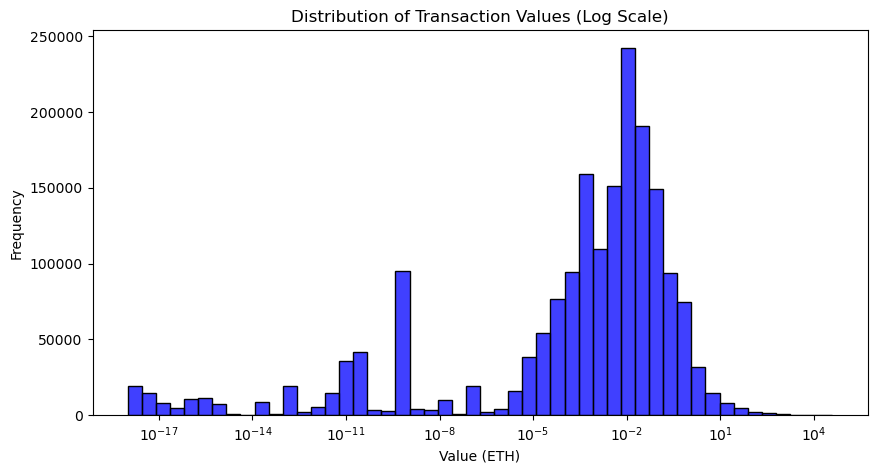

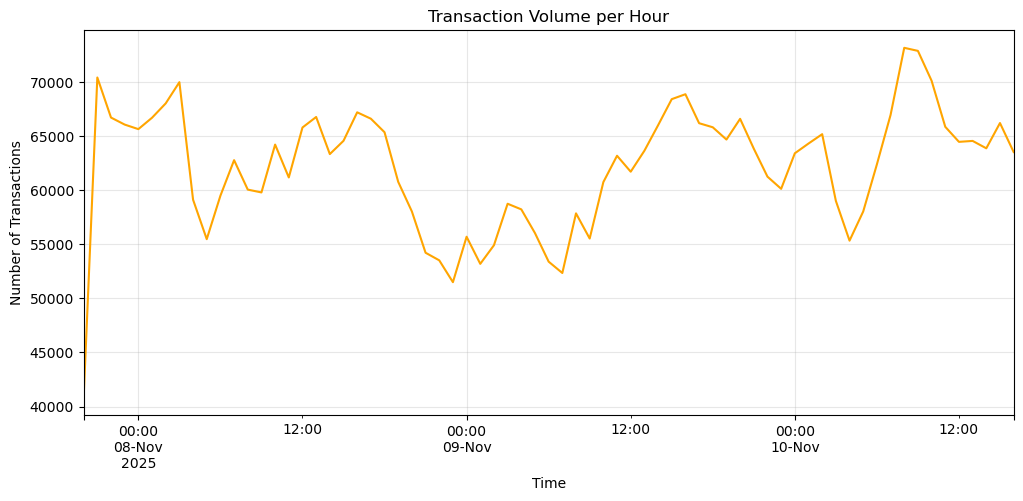

--- Top 5 Senders by Transaction Count ---
from_address
0x28c6c06298d514db089934071355e5743bf21d60    30455
0x559432e18b281731c054cd703d4b49872be4ed53    29382
0x4838b106fce9647bdf1e7877bf73ce8b0bad5f97    28659
0xf70da97812cb96acdf810712aa562db8dfa3dbef    27349
0x974caa59e49682cda0ad2bbe82983419a2ecc400    23155
Name: count, dtype: int64

--- Top 5 Receivers by Transaction Count ---
to_address
0xdac17f958d2ee523a2206206994597c13d831ec7    592958
0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48    324191
0xdf9aceddd8a8c130dfe3015c0b1b507cf6571fc9     72461
0x904567252d8f48555b7447c67dca23f0372e16be     54318
0xa69babef1ca67a37ffaf7a485dfff3382056e78c     53838
Name: count, dtype: int64

Percentage of senders who only sent exactly 1 transaction: 61.69%


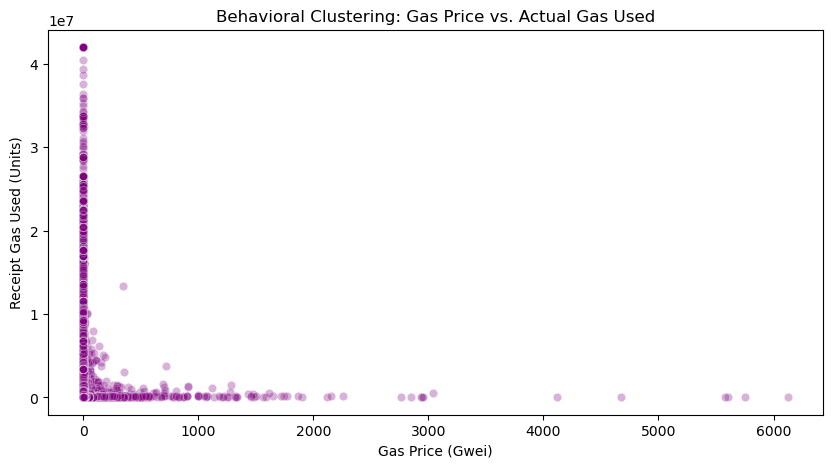

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the already preprocessed dataset
df = pd.read_csv('eth_tx_last4days_clean.csv')

# ==========================================
# Univariate Analysis
# ==========================================

# 1. The Value Distribution
# Relying directly on your pre-calculated 'value_eth' column
non_zero_tx = df[df['value_eth'] > 0]
plt.figure(figsize=(10, 5))
sns.histplot(non_zero_tx['value_eth'], bins=50, log_scale=True, color='blue')
plt.title('Distribution of Transaction Values (Log Scale)')
plt.xlabel('Value (ETH)')
plt.ylabel('Frequency')
plt.show()

# 2. Transaction Volume Over Time (Bursts & Heartbeats)
plt.figure(figsize=(12, 5))
# Converting block_timestamp to datetime inline strictly for setting the plot index
df.set_index(pd.to_datetime(df['block_timestamp'])).resample('h')['hash'].count().plot(color='orange')
plt.title('Transaction Volume per Hour')
plt.ylabel('Number of Transactions')
plt.xlabel('Time')
plt.grid(True, alpha=0.3)
plt.show()


# ==========================================
# Graph-Specific EDA
# ==========================================

# 1. The "Whale" Senders and Receivers (Degree Distribution proxy)
print("--- Top 5 Senders by Transaction Count ---")
print(df['from_address'].value_counts().head(5))

print("\n--- Top 5 Receivers by Transaction Count ---")
print(df['to_address'].value_counts().head(5))

# 2. Identifying "Dust" vs. "Active" Wallets
sender_counts = df['from_address'].value_counts()
one_time_senders = (sender_counts == 1).sum() / len(sender_counts) * 100
print(f"\nPercentage of senders who only sent exactly 1 transaction: {one_time_senders:.2f}%")

# 3. Gas Usage as a Behavioral Feature
plt.figure(figsize=(10, 5))
# Scaling gas_price to Gwei inline purely for visual readability on the axis
sns.scatterplot(x=df['gas_price'] / (10**9), y=df['receipt_gas_used'], alpha=0.3, color='purple')
plt.title('Behavioral Clustering: Gas Price vs. Actual Gas Used')
plt.xlabel('Gas Price (Gwei)')
plt.ylabel('Receipt Gas Used (Units)')
plt.show()

### What these charts show and what they tell us

**Chart 1 — Distribution of Transaction Values (log scale):**  
Plots the histogram of `value_eth` for all non-zero transactions on a logarithmic x-axis. Log scale is essential here because ETH transaction values span many orders of magnitude — from fractions of a wei to thousands of ETH — and a linear axis would collapse the entire distribution into a single spike near zero.

The distribution is heavily **right-skewed**: the vast majority of transactions move small amounts, but a long tail of high-value transfers exists. This power-law-like shape is typical of financial networks and means that a small number of "whale" transactions account for a disproportionate share of total value transferred. 

**Chart 2 — Transaction Volume per Hour:**  
Plots the count of transactions binned into 1-hour windows across the full 4-day window. This reveals the **temporal rhythm** of the network — whether activity is steady or comes in bursts, and whether there are day/night cycles.

Regular peaks and troughs indicate human-driven activity (people are more active during waking hours); an unusually flat or erratic pattern could indicate automated activity. This plot is the starting point for the deeper temporal analysis in Section 5.

**Top senders/receivers (printed):**  
The "whale" addresses — wallets with disproportionately high transaction counts — are proxy degree hubs in the graph. High out-degree senders are candidates for bot wallets or exchange hot wallets; high in-degree receivers are likely exchange deposit addresses, DeFi contracts, or mixer destinations.

**One-time senders (printed percentage):**  
The fraction of sender addresses that sent exactly one transaction during the 4-day window. A high percentage indicates that most wallets in the graph are **leaf nodes** — they appear once and disappear.

**Chart 3 — Gas Price vs Gas Used (scatter):**  
Each dot is one transaction. X-axis = gas price in Gwei (what the sender paid per unit of computation); Y-axis = gas actually used (how much computation the transaction required).

**Behavioural clusters** emerge naturally: simple ETH transfers cluster at low, fixed gas usage (~21,000 units); smart contract interactions spread across a wide range of gas used. Wallets that consistently choose very high gas prices are likely bots or high-priority traders who need fast inclusion. This scatter is a behavioural fingerprint that could be used as an edge feature.


## 2. Gas Price Over Time — Network Congestion Proxy

Average gas price per hour is a reliable proxy for **network congestion**: when many users compete for block space, gas prices spike. Sustained high gas prices indicate periods of heavy demand — DeFi activity, NFT mints, arbitrage bots. Drops indicate quieter periods.

For fraud detection, sudden gas price spikes can correlate with known events (liquidations, exploits) and may help contextualise anomalous transaction clusters in the graph.


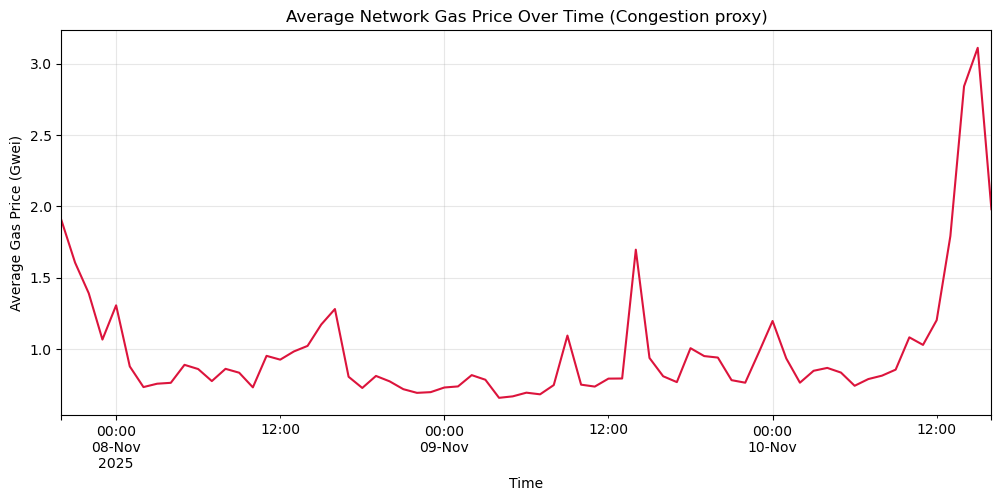

In [2]:
plt.figure(figsize=(12, 5))
# Convert to Gwei for readability and plot the average gas price per hour
df['gas_price_gwei'] = df['gas_price'] / (10**9)
df.set_index(pd.to_datetime(df['block_timestamp'])).resample('h')['gas_price_gwei'].mean().plot(color='crimson')

plt.title('Average Network Gas Price Over Time (Congestion proxy)')
plt.ylabel('Average Gas Price (Gwei)')
plt.xlabel('Time')
plt.grid(True, alpha=0.3)
plt.show()

### What this chart shows and what it tells us

The line plot traces average gas price (in Gwei) across the 4-day window, with each point representing one hour.

Key things to look for:
- **Spikes** indicate moments of network congestion — high demand for block inclusion. These often correlate with major DeFi events, NFT drops, or automated arbitrage cascades.
- **Baseline level** shows the typical cost of transacting during this period.
- **Correlation with volume** (Section 1): if gas spikes coincide with volume peaks, the congestion is demand-driven. If gas rises while volume is flat, a small number of high-priority transactions (e.g. bots bidding aggressively) are the cause.

## 3. Transaction Type Split — ETH Transfers vs Token/Contract Calls

Not all Ethereum transactions move ETH. Transactions with `value_eth = 0` are typically calls to smart contracts — ERC-20 token transfers, DeFi interactions, NFT operations, or any other on-chain computation. Those with `value_eth > 0` are direct ETH transfers between wallets.

This split is fundamental to understanding the graph: the two types represent structurally different edges. Token/contract transactions create connections that are invisible to a value-only analysis, and mixing them without distinction would conflate very different behaviours.


/var/folders/zf/wylf1g6j40g9pz8j5wtw1hhw0000gn/T/ipykernel_1721/3766021946.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='tx_type', palette='viridis')


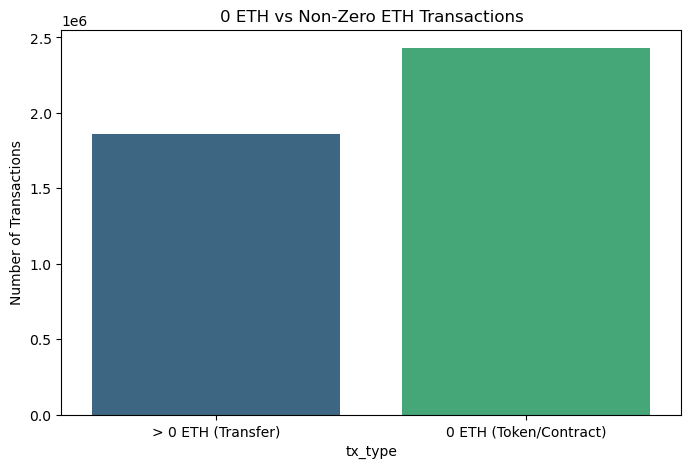

In [3]:
# zero vs non-zero value transactions# Categorize transactions
df['tx_type'] = df['value_eth'].apply(lambda x: '0 ETH (Token/Contract)' if x == 0 else '> 0 ETH (Transfer)')

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='tx_type', palette='viridis')
plt.title('0 ETH vs Non-Zero ETH Transactions')
plt.ylabel('Number of Transactions')
plt.show()

### What this chart shows and what it tells us

A simple count bar chart comparing the number of zero-ETH transactions (`0 ETH — Token/Contract`) against non-zero ETH transactions (`> 0 ETH — Transfer`).

**Key finding:** on Ethereum, zero-value transactions typically outnumber ETH transfers significantly. This reflects the dominance of token activity (ERC-20 transfers, Uniswap swaps, lending protocol interactions) over simple ETH-to-ETH transfers.

## 4. Edge Weight Distribution — Repeated Interactions

In a transaction graph, an **edge weight** between two addresses is the number of times they transacted with each other during the observation window. A weight of 1 means a one-off interaction; a weight of 100 means the same pair transacted 100 times.

High edge weights are a critical signal for fraud: wash trading by definition involves the same pair of wallets transacting repeatedly, and mixers often maintain persistent connections to relay wallets. Mapping the distribution of edge weights tells us how much of the graph is built on repeated vs one-off connections.


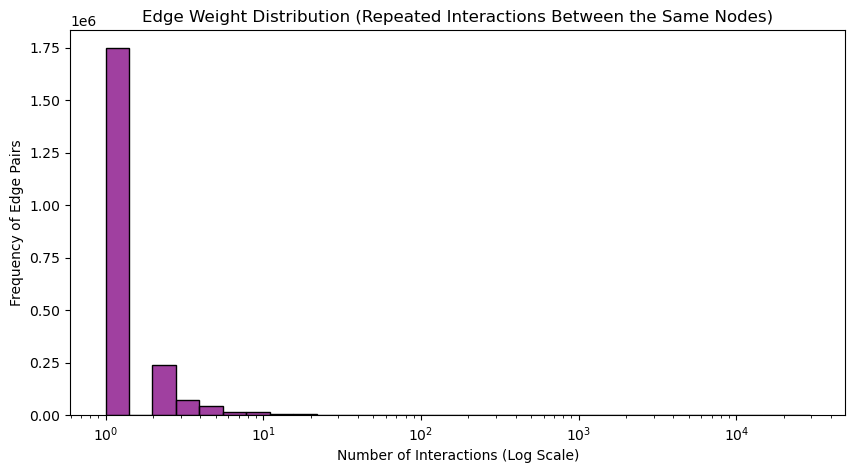

--- Top 5 Strongest Connections (Highest Edge Weights) ---
                                       from_address  \
716155   0x559432e18b281731c054cd703d4b49872be4ed53   
1740202  0xcf076007e6c36cfb1eb2cd36ad66405fec7d0b31   
676636   0x5050f69a9786f081509234f1a7f4684b5e5b76c9   
281320   0x21b92a8fe81f6f300c03d8a3a403aac32c2facc2   
606765   0x4838b106fce9647bdf1e7877bf73ce8b0bad5f97   

                                         to_address  interaction_count  
716155   0xdac17f958d2ee523a2206206994597c13d831ec7              29381  
1740202  0xdead0000708fbf85a7d4ada5243fb460aee2bb0c              17212  
676636   0xff00000000000000000000000000000000008453              17163  
281320   0x21b92a8fe81f6f300c03d8a3a403aac32c2facc2              15273  
606765   0xc6093fd9cc143f9f058938868b2df2daf9a91d28              11875  


In [4]:
# measure repetitive transactional behavior
# Group by sender and receiver to count repeated interactions
edge_weights = df.groupby(['from_address', 'to_address']).size().reset_index(name='interaction_count')

plt.figure(figsize=(10, 5))
# Using log scale because repeated interactions usually follow a massive power law
sns.histplot(edge_weights['interaction_count'], bins=30, log_scale=True, color='purple')
plt.title('Edge Weight Distribution (Repeated Interactions Between the Same Nodes)')
plt.xlabel('Number of Interactions (Log Scale)')
plt.ylabel('Frequency of Edge Pairs')
plt.show()

# See the strongest individual connections
print("--- Top 5 Strongest Connections (Highest Edge Weights) ---")
print(edge_weights.sort_values(by='interaction_count', ascending=False).head(5))

### What this chart shows and what it tells us

**The histogram (log scale):** plots the distribution of `interaction_count` — how many times each unique sender-receiver pair appeared — on a log x-axis. Most pairs interact only once (left side of the distribution); a small but meaningful tail of pairs interact dozens or hundreds of times.

The log scale is necessary because edge weight distributions in real-world networks follow a **power law**: exponentially many pairs with low weight, exponentially few with high weight. A linear axis would hide the tail entirely.

**The top-5 table (printed):** the five sender-receiver pairs with the highest interaction count. These are the densest edges in the graph. Pairs appearing hundreds of times in a 4-day window are almost certainly automated — either exchange internal transfers, bot activity, or coordinated fraud. These addresses are prime candidates for manual inspection and should be cross-referenced against the fraud labels in the motif feature dataset.


## 5. Network Heartbeat — Day/Night Volume Patterns

Transaction volume on Ethereum follows a **circadian rhythm** driven by human activity patterns. Understanding when the network is active — and when it is quiet.

**Contextualising anomalies:** a burst of activity at 3am UTC looks very different from the same burst at 2pm UTC. Nighttime spikes are more likely to be automated.

This section refines the simple hourly volume plot from Section 1 by explicitly annotating nighttime windows and computing the average hourly rate for day vs night separately.


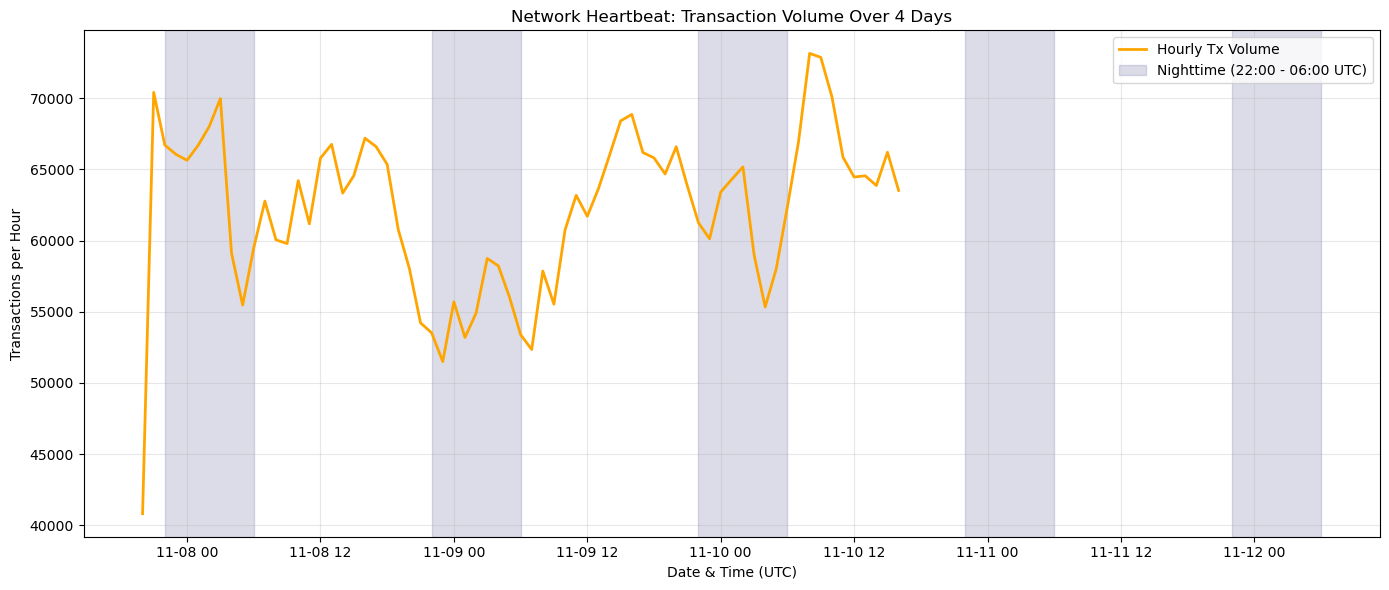

/var/folders/zf/wylf1g6j40g9pz8j5wtw1hhw0000gn/T/ipykernel_1721/3751280447.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_hourly, x='time_of_day', y='tx_count', palette=['skyblue', 'midnightblue'])


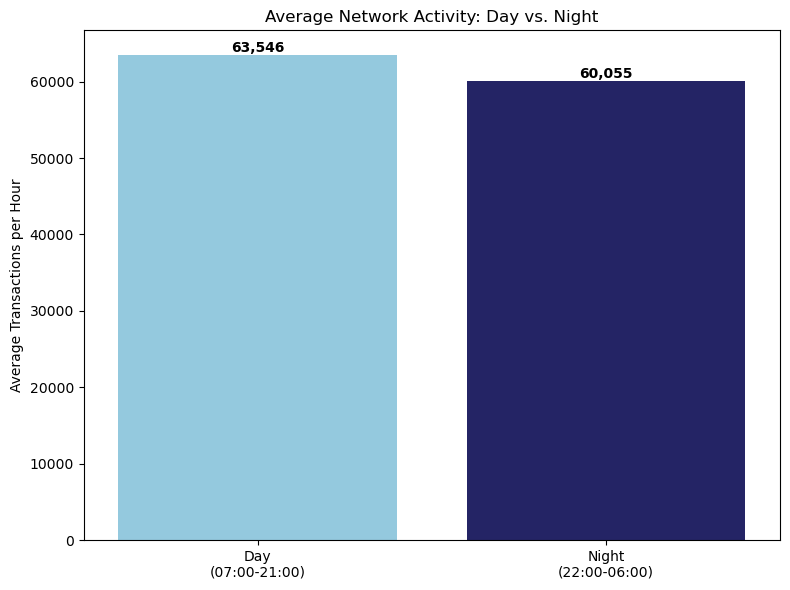

In [5]:
import numpy as np

# Load the clean dataset
df = pd.read_csv('eth_tx_last4days_clean.csv')
df['block_timestamp'] = pd.to_datetime(df['block_timestamp'])

# ==========================================
# Plot 1: Timeline with Nighttime Shading
# ==========================================

# Aggregate volume by hour
hourly_vol = df.set_index('block_timestamp').resample('h')['hash'].count().reset_index()
hourly_vol.columns = ['timestamp', 'tx_count']

plt.figure(figsize=(14, 6))
plt.plot(hourly_vol['timestamp'], hourly_vol['tx_count'], color='orange', label='Hourly Tx Volume', linewidth=2)

# Highlight nighttime hours (22:00 to 06:00 UTC) with vertical shading
start_date = hourly_vol['timestamp'].min().floor('D')
end_date = hourly_vol['timestamp'].max().ceil('D')
date_range = pd.date_range(start_date, end_date)

for date in date_range:
    # Night starts at 22:00 of the current day
    night_start = date + pd.Timedelta(hours=22)
    # Night ends at 06:00 of the NEXT day
    night_end = night_start + pd.Timedelta(hours=8)
    
    # Apply shading. Only add the label to the legend once.
    plt.axvspan(night_start, night_end, color='midnightblue', alpha=0.15, 
                label='Nighttime (22:00 - 06:00 UTC)' if date == date_range[0] else "")

plt.title('Network Heartbeat: Transaction Volume Over 4 Days')
plt.xlabel('Date & Time (UTC)')
plt.ylabel('Transactions per Hour')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================================
# Plot 2: Average Hourly Rate (Day vs. Night)
# ==========================================

# Classify each transaction based on its hour
df['hour'] = df['block_timestamp'].dt.hour
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 6))
df['time_of_day'] = df['is_night'].map({True: 'Night\n(22:00-06:00)', False: 'Day\n(07:00-21:00)'})

# To get a fair comparison, calculate the average transactions per hour for each category
# Group by Date, Hour, and Time of Day to get exact counts per individual hour
hourly_counts = df.groupby([df['block_timestamp'].dt.date, 'hour', 'time_of_day'])['hash'].count().reset_index(name='tx_count')

# Calculate the mean volume per hour block
avg_hourly = hourly_counts.groupby('time_of_day')['tx_count'].mean().reset_index()

plt.figure(figsize=(8, 6))
# Using a custom color palette for Day (Sky blue) and Night (Dark blue)
sns.barplot(data=avg_hourly, x='time_of_day', y='tx_count', palette=['skyblue', 'midnightblue'])
plt.title('Average Network Activity: Day vs. Night')
plt.ylabel('Average Transactions per Hour')
plt.xlabel('')

# Add actual numbers on top of the bars for clarity
for index, row in avg_hourly.iterrows():
    plt.text(index, row['tx_count'], f"{int(row['tx_count']):,}", color='black', ha="center", va="bottom", fontweight='bold')

plt.tight_layout()
plt.show()

### What these charts show and what they tell us

**Chart 1 — Network Heartbeat with nighttime shading:**  
The orange line shows hourly transaction count over the full 4-day window. Dark blue shaded bands mark nighttime hours (22:00–06:00 UTC). This makes the day/night pattern immediately visible.

Clear daytime peaks and nighttime troughs indicate that **human behaviour drives the majority of network activity**. If the volume pattern were flat or showed activity *only* at night, it would point toward automation or activity from a specific time zone cluster.

For fraud detection: automated bots typically operate 24/7 and would show up as anomalously high activity during the nighttime troughs — periods where most human traders are offline. An address that is as active at 3am as at 3pm is a candidate for automated behaviour.

**Chart 2 — Average transactions per hour: Day vs Night:**  
A bar chart quantifying the day/night difference numerically. The exact counts are annotated on each bar.

The gap between daytime and nighttime average volume gives a **baseline ratio** for what counts as "suspiciously active at night."


## 6. Bot Detection — Inter-Transaction Time Deltas

Automated wallets (bots) leave a very specific temporal signature: they fire transactions at **mechanically regular intervals**, often driven by a script that submits a new transaction as soon as the previous one is confirmed, or on a fixed timer.

This analysis focuses on **active wallets** (≥10 transactions in the window) and measures the time elapsed between consecutive transactions from the same sender. A human wallet will have irregular, widely-spaced intervals. A bot wallet will show a spike at a very specific delta — often near 0 seconds (submit-on-confirmation) or at exactly 12 seconds (one Ethereum block time).


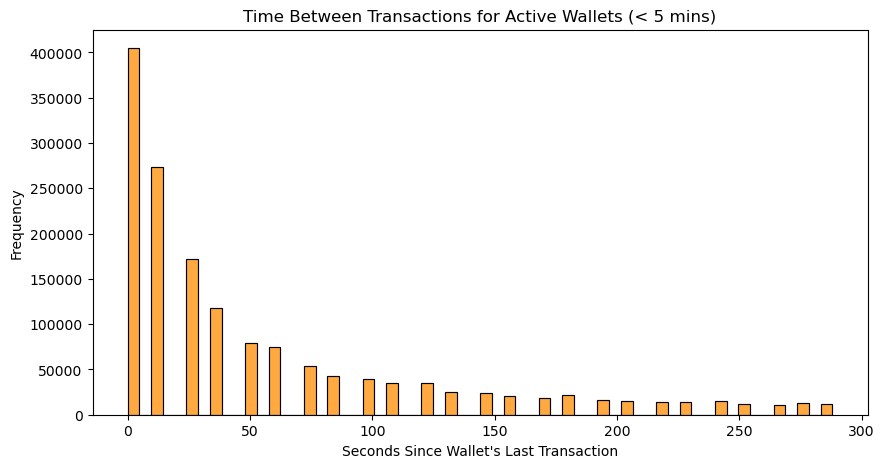

In [6]:
# bot detection via time delta between transactions
# Filter for addresses that have made at least 10 transactions to avoid noise
active_senders = df['from_address'].value_counts()
active_senders = active_senders[active_senders >= 10].index

df_active = df[df['from_address'].isin(active_senders)].copy()

# Sort by sender and time, then calculate the time difference between their transactions
df_active = df_active.sort_values(by=['from_address', 'block_timestamp'])
df_active['time_since_last_tx'] = df_active.groupby('from_address')['block_timestamp'].diff().dt.total_seconds()

plt.figure(figsize=(10, 5))
# Plotting time deltas under 5 minutes (300 seconds) to zoom in on rapid-fire behavior
rapid_fire = df_active[df_active['time_since_last_tx'] < 300]
sns.histplot(rapid_fire['time_since_last_tx'], bins=60, color='darkorange')

plt.title('Time Between Transactions for Active Wallets (< 5 mins)')
plt.xlabel('Seconds Since Wallet\'s Last Transaction')
plt.ylabel('Frequency')
# A massive spike near 0 or exactly 12 indicates bot behavior
plt.show()

### What this chart shows and what it tells us

The histogram plots the **time in seconds between consecutive transactions** for the same sender, filtered to only show deltas under 5 minutes (300 seconds). Only wallets with at least 10 transactions are included to avoid noise from coincidentally close one-off transactions.

**What to look for:**
- **A spike near 0 seconds** — the sender submits a new transaction the moment the previous one lands. This is characteristic of MEV bots, arbitrage bots, or high-frequency automated strategies.
- **A spike at exactly 12 seconds** — one Ethereum block time. A bot monitoring the chain and reacting every block would produce this pattern.
- **A broad, smooth distribution** — characteristic of human behaviour with no precise timing.


## Summary

| Analysis | Key finding |
|---|---|
| **Value distribution** | Power-law shape — log-transform required before use as edge feature |
| **Temporal volume** | Clear circadian pattern — most activity is human-driven daytime traffic |
| **Node degrees** | A small number of whale/hub addresses dominate send/receive counts; most wallets are one-time senders |
| **Gas price** | Hourly average tracks congestion — spikes often coincide with automated or high-priority activity |
| **Tx type split** | Zero-ETH contract calls outnumber ETH transfers — both edge types must be retained in the graph |
| **Edge weights** | Distribution follows a power law; the highest-weight pairs are candidates for automated or fraudulent activity |
| **Day vs night** | Daytime volume is significantly higher — nighttime activity above the baseline is a bot signal |
| **Inter-tx time deltas** | Spikes near 0s or 12s in active wallets indicate automated behaviour — a strong node-level feature candidate |
